In [1]:
from langgraph.graph import StateGraph, START, END,MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain.messages import RemoveMessage
import os

In [2]:
load_dotenv()

True

In [3]:
chat_model = os.getenv('CHAT_MODEL')
llm = init_chat_model(model=chat_model)
llm.invoke('Hi')

AIMessage(content='Hi! 👋 How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 7, 'total_tokens': 21, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-nano-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EFKqf38TNwHpOVzUbMX5LKbWsC96J', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a024cc-5b52-7b40-b446-85e60bbaf34e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 14, 'total_tokens': 21, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [4]:
checkpointer = InMemorySaver()

In [5]:
def chat_bot(state:MessagesState):
    response = llm.invoke(state["messages"])
    return {"messages":[response]}

In [10]:
from typing import Literal

In [11]:
def route_messages(state: MessagesState) -> Literal["delete_old_messages", "chat_bot"]:
    max_messages = 5
    message_count = len(state["messages"])

    print(f"Messages before routing: {message_count}")

    if message_count > max_messages:
        return "delete_old_messages"

    return "chat_bot"

In [6]:
def delete_old_messages(state: MessagesState):
    max_messages = 5
    messages = state["messages"]

    total_count = len(messages)
    print(f"Total messages before deletion: {total_count}")

    # Keep the latest max_messages and remove older messages
    to_remove = messages[:-max_messages]

    if not to_remove:
        print(f"Last {max_messages} message count: {total_count}")
        return {}

    updated_state = {
        "messages": [
            RemoveMessage(id=message.id)
            for message in to_remove
        ]
    }

    remaining_count = total_count - len(to_remove)

    print(f"Messages removed: {len(to_remove)}")
    print(f"Last N message count: {remaining_count}")

    return updated_state

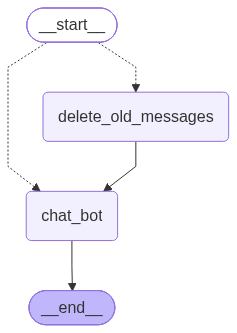

In [12]:
graph = StateGraph(MessagesState)

# graph.add_node('chat_bot',chat_bot)
graph.add_node('chat_bot',chat_bot)
graph.add_node('delete_old_messages',delete_old_messages)


graph.add_conditional_edges(
    START,
    route_messages,
    {
        "delete_old_messages": "delete_old_messages",
        "chat_bot": "chat_bot",
    },
)
graph.add_edge("delete_old_messages", "chat_bot")
graph.add_edge("chat_bot", END)

checkpointer_graph = graph.compile(checkpointer)

## Display
from IPython.display import Image, display
display(Image(checkpointer_graph.get_graph().draw_mermaid_png()))

In [ ]:
print('To end: exit,q,quit')

_user_id = None 

while True:

    if not _user_id : 
        _user_id = input('User id: ')

    _input = input('User: ')
    
    if _input in ('q','quit','exit'):
        _user_id = None
        break
    
    message = {
        'messages':[
            {
                'role':'user',
                'content':_input
            }
        ]
    }

    config = {
        'configurable':{
            'thread_id':_user_id
        }
    }

    response  = checkpointer_graph.invoke(message,config)
    print('User: ', _input)
    print('AI: ',response["messages"][-1].content)

To end: exit,q,quit
Messages before routing: 6
Total messages before deletion: 6
Messages removed: 1
Last N message count: 5
User:  write 10 lines
AI:  1. The sun rose quietly over the horizon.  
2. Morning light filled every corner of the room.  
3. I took a deep breath and began my day.  
4. Plans formed as my thoughts turned into actions.  
5. A soft breeze carried distant sounds.  
6. Small moments became meaningful in the end.  
7. Challenges appeared, but I kept moving forward.  
8. I learned something new with each step.  
9. By evening, I felt proud of my progress.  
10. Tomorrow would bring new chances to try again.
Messages before routing: 7
Total messages before deletion: 7
Messages removed: 2
Last N message count: 5
User:  my name is tel
AI:  Nice to meet you, Tel! What would you like to do next?
Messages before routing: 7
Total messages before deletion: 7
Messages removed: 2
Last N message count: 5
User:  write 10 lines
AI:  1. Hi Tel, welcome and good day!  
2. You have a